In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_products.csv")

print(df.head())

  Category                        Product Name    Price  \
0  Laptops          Asus VivoBook X441NA-GA190  $295.99   
1  Laptops  Prestigio SmartBook 133S Dark Grey     $299   
2  Laptops       Prestigio SmartBook 133S Gold     $299   
3  Laptops                       Aspire E1-510  $306.99   
4  Laptops                   Lenovo V110-15IAP  $321.94   

                                         Description  Reviews  \
0  Asus VivoBook X441NA-GA190 Chocolate Black, 14...      NaN   
1  Prestigio SmartBook 133S Dark Grey, 13.3" FHD ...      NaN   
2  Prestigio SmartBook 133S Gold, 13.3" FHD IPS, ...      NaN   
3    15.6", Pentium N3520 2.16GHz, 4GB, 500GB, Linux      NaN   
4  Lenovo V110-15IAP, 15.6" HD, Celeron N3350 1.1...      NaN   

                                         Product URL  
0  https://webscraper.io/test-sites/e-commerce/al...  
1  https://webscraper.io/test-sites/e-commerce/al...  
2  https://webscraper.io/test-sites/e-commerce/al...  
3  https://webscraper.io/test-site

In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(114, 6)

Columns:
Index(['Category', 'Product Name', 'Price', 'Description', 'Reviews',
       'Product URL'],
      dtype='object')

Data Types:
Category         object
Product Name     object
Price            object
Description      object
Reviews         float64
Product URL      object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Category      114 non-null    object 
 1   Product Name  114 non-null    object 
 2   Price         114 non-null    object 
 3   Description   114 non-null    object 
 4   Reviews       0 non-null      float64
 5   Product URL   114 non-null    object 
dtypes: float64(1), object(5)
memory usage: 5.5+ KB


In [4]:
print(df.isnull().sum())

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Category          0
Product Name      0
Price             0
Description       0
Reviews         114
Product URL       0
dtype: int64
Category          0.0
Product Name      0.0
Price             0.0
Description       0.0
Reviews         100.0
Product URL       0.0
dtype: float64


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

print(df["Price"].head())

0    295.99
1    299.00
2    299.00
3    306.99
4    321.94
Name: Price, dtype: float64


In [8]:
# Explicitly convert to string type first to ensure .str accessor works
df["Reviews"] = df["Reviews"].astype(str)

df["Reviews"] = (
    df["Reviews"]
    .str.replace("reviews", "", regex=False)
    .str.strip()
)

df["Reviews"] = pd.to_numeric(
    df["Reviews"],
    errors="coerce"
)

print(df["Reviews"].head())

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Reviews, dtype: float64


Category
Laptops    88
Tablets    19
Phones      7
Name: count, dtype: int64


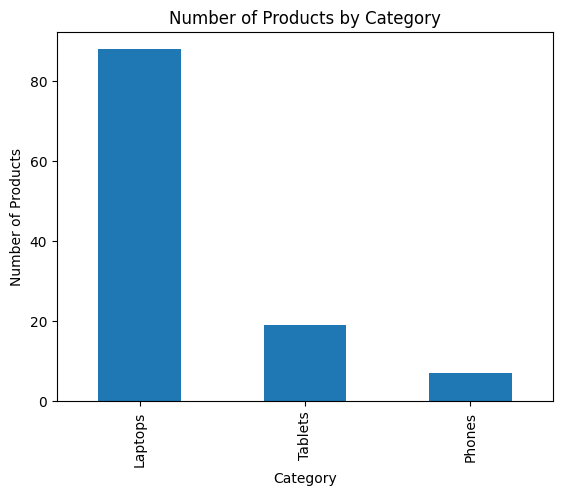

In [9]:
category_count = df["Category"].value_counts()

print(category_count)

category_count.plot(kind="bar")

plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

Category
Laptops    898.435568
Phones     257.990000
Tablets    224.990000
Name: Price, dtype: float64


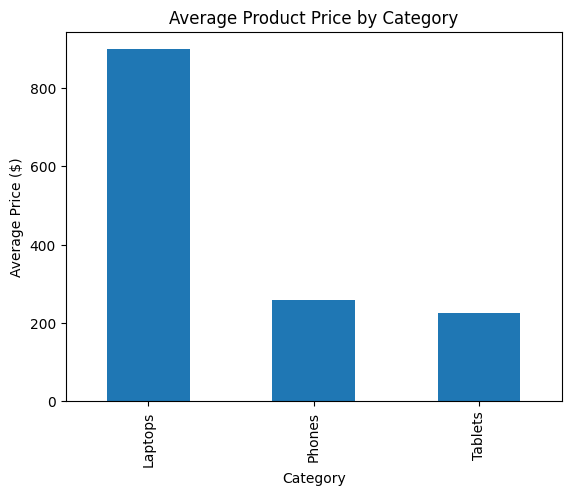

In [10]:
avg_price = df.groupby("Category")["Price"].mean()

print(avg_price)

avg_price.plot(kind="bar")

plt.title("Average Product Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price ($)")

plt.show()

In [11]:
expensive_products = df.sort_values(
    by="Price",
    ascending=False
)

print(
    expensive_products[
        ["Product Name", "Category", "Price"]
    ].head(10)
)

                                  Product Name Category    Price
87  Asus ROG Strix SCAR Edition GL503VM-ED115T  Laptops  1799.00
85               Asus ROG Strix GL702ZC-GC154T  Laptops  1769.00
86               Asus ROG Strix GL702ZC-GC209T  Laptops  1769.00
83                          Lenovo Legion Y720  Laptops  1399.00
84               Asus ROG Strix GL702VM-GC146T  Laptops  1399.00
82           Asus ASUSPRO B9440UA-GV0279R Gray  Laptops  1381.13
81       Toshiba Portege X20W-D-10V Black/Blue  Laptops  1366.32
80              Lenovo ThinkPad Yoga 370 Black  Laptops  1362.24
79                        Lenovo ThinkPad T470  Laptops  1349.23
78            Apple MacBook Pro 13" Space Gray  Laptops  1333.00


In [12]:
most_reviewed = df.sort_values(
    by="Reviews",
    ascending=False
)

print(
    most_reviewed[
        ["Product Name", "Category", "Price", "Reviews"]
    ].head(10)
)

                             Product Name Category   Price  Reviews
0              Asus VivoBook X441NA-GA190  Laptops  295.99      NaN
1      Prestigio SmartBook 133S Dark Grey  Laptops  299.00      NaN
2           Prestigio SmartBook 133S Gold  Laptops  299.00      NaN
3                           Aspire E1-510  Laptops  306.99      NaN
4                       Lenovo V110-15IAP  Laptops  321.94      NaN
5  Hewlett Packard 250 G6 Dark Ash Silver  Laptops  364.46      NaN
6             Acer Aspire 3 A315-31 Black  Laptops  372.70      NaN
7                Acer Aspire A315-31-C33J  Laptops  379.94      NaN
8               Acer Aspire ES1-572 Black  Laptops  379.95      NaN
9                   Acer Aspire 3 A315-21  Laptops  393.88      NaN


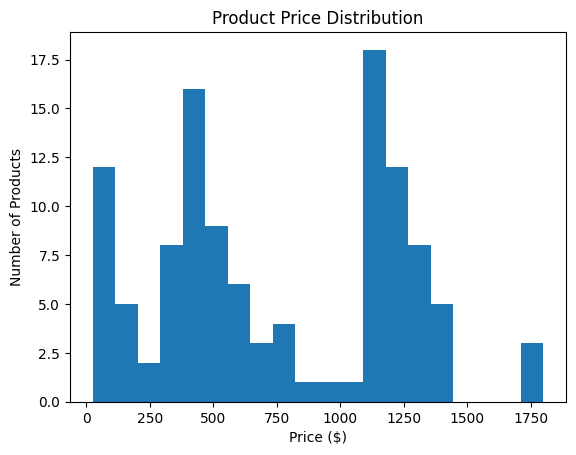

In [14]:
plt.hist(df["Price"], bins=20)

plt.title("Product Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.show()

In [15]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nPrice Statistics:")
print(df["Price"].describe())

print("\nReview Statistics:")
print(df["Reviews"].describe())

Missing Values:
Category          0
Product Name      0
Price             0
Description       0
Reviews         114
Product URL       0
dtype: int64

Duplicate Rows:
0

Price Statistics:
count     114.000000
mean      746.869035
std       467.461378
min        24.990000
25%       383.432500
50%       606.990000
75%      1166.085000
max      1799.000000
Name: Price, dtype: float64

Review Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Reviews, dtype: float64
